# Chunk-Level XGBoost (Deployment-Safe Features)

Trains XGBoost on deployment-safe features only and evaluates at chunk level.

**Features excluded (not available at prediction time):**  
`Travel_Distance`, `same_aisle`, `same_lockey`, `same_location`, `same_level`, `diff_level`, `time_of_day`, `day_of_week`, `hour`

In [2]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import importlib
import feature_engineer
importlib.reload(feature_engineer)
from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH         = Path("../data/processed")
WAREHOUSE    = "OE"
WORKCODES    = ["10", "20", "30"]
MAX_TIME     = 300
BLOCK_SIZE   = 50
RANDOM_STATE = 2026

# Features not available at prediction time — excluded from XGBoost
NOT_AVAILABLE = [
    "Travel_Distance",
    "same_aisle", "same_lockey", "same_location", "same_level", "diff_level",
    "time_of_day", "day_of_week", "hour",
]


In [3]:
def resolve_data_path(warehouse):
    return PATH / f"{warehouse.lower()}_detailed.parquet"


_df_raw = pd.read_parquet(resolve_data_path(WAREHOUSE))
_df_raw["WorkCode"] = _df_raw["WorkCode"].astype(str).apply(
    lambda x: x.split(".")[0] if isinstance(x, str) else x
)
WORKCODES = sorted(_df_raw["WorkCode"].dropna().unique().tolist())
print(f"WorkCodes found: {WORKCODES}")
del _df_raw



def load_engineered_data(warehouse, workcode, max_time=300):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=resolve_data_path(warehouse),
        warehouse=warehouse,
        max_time=max_time,
        work_code=workcode,
    )
    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"]     = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    features = [f for f in features_all if f not in NOT_AVAILABLE]
    cat_cols = [c for c in cat_cols_all if c not in NOT_AVAILABLE]
    return d, features, cat_cols


def split_by_days(df, test_ratio=0.15):
    all_days    = sorted(df["date"].dropna().unique())
    n_test_days = max(1, int(round(len(all_days) * test_ratio)))
    test_days   = all_days[-n_test_days:]
    train_df    = df[df["date"] < test_days[0]].copy()
    test_df     = df[df["date"].isin(test_days)].copy()
    return train_df, test_df, test_days


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(test_df[features],  columns=cat_cols, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test


def eval_predictions(y_true, pred):
    return {
        "r2":   r2_score(y_true, pred),
        "mae":  mean_absolute_error(y_true, pred),
        "rmse": np.sqrt(mean_squared_error(y_true, pred)),
    }


def make_test_blocks(test_df, block_size=BLOCK_SIZE):
    d = test_df.sort_values(["UserID", "Timestamp"]).copy()
    blocks, block_rows = [], []
    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.sort_values("Timestamp").reset_index().rename(columns={"index": "orig_index"}).copy()
        for start in range(0, len(g), block_size):
            chunk = g.iloc[start:start + block_size].copy()
            if len(chunk) < block_size:
                continue
            if chunk["WorkCode"].nunique() != 1:
                continue
            if (chunk["Time_Delta_sec"] > MAX_TIME).any():
                continue
            block_id = f"{uid}_{day}_{start // block_size}"
            chunk["BlockID"] = block_id
            block_rows.append(chunk)
            blocks.append({
                "BlockID":     block_id,
                "UserID":      uid,
                "date":        day,
                "WorkCode":    chunk["WorkCode"].iloc[0],
                "n_tasks":     len(chunk),
                "actual_time": chunk["Time_Delta_sec"].sum(),
                "start_ts":    chunk["Timestamp"].min(),
                "end_ts":      chunk["Timestamp"].max(),
            })
    block_df     = pd.DataFrame(blocks)
    block_rows_df = pd.concat(block_rows, ignore_index=True) if block_rows else pd.DataFrame()
    return block_df, block_rows_df


WorkCodes found: ['10', '20', '30']


In [4]:
all_task_results  = []
all_block_results = []
all_block_detail  = []

xgb_params = dict(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:tweedie",
    tweedie_variance_power=1.3,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

for wc in WORKCODES:
    print(f"\n{'='*50}")
    print(f"WorkCode {wc}")
    print(f"{'='*50}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, test_days = split_by_days(df_wc)
    print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
    print(f"Features: {features}")

    y_train = train_df["Time_Delta_sec"].astype(float)
    y_test  = test_df["Time_Delta_sec"].astype(float)

    X_train, X_test = make_X(train_df, test_df, features, cat_cols)

    t0    = time.perf_counter()
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    runtime = time.perf_counter() - t0

    all_task_results.append({
        "Warehouse":    WAREHOUSE,
        "WorkCode":     wc,
        "n_train_rows": len(train_df),
        "n_test_rows":  len(test_df),
        "runtime_sec":  runtime,
        **eval_predictions(y_test, preds)
    })

    # Block-level evaluation
    block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_df) == 0:
        print(f"No valid blocks for WC {wc}")
        continue

    temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
    temp["pred"] = preds
    block_rows_df = block_rows_df.merge(temp[["orig_index", "pred"]], on="orig_index", how="left")

    block_pred = (
        block_rows_df.groupby("BlockID")
        .agg(
            actual_time=("Time_Delta_sec", "sum"),
            pred=("pred", "sum"),
            WorkCode=("WorkCode", "first"),
            UserID=("UserID", "first"),
            date=("date", "first"),
            n_tasks=("Time_Delta_sec", "size"),
        )
        .reset_index()
    )

    metrics = eval_predictions(block_pred["actual_time"], block_pred["pred"])
    print(f"  Blocks: {len(block_pred)} | MAE: {metrics['mae']:.1f}s | "
          f"MAE/task: {metrics['mae']/BLOCK_SIZE:.3f}s | R²: {metrics['r2']:.4f}")

    all_block_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode":  wc,
        "n_blocks":  len(block_pred),
        **metrics
    })
    block_pred["Warehouse"] = WAREHOUSE
    all_block_detail.append(block_pred)

task_results_df  = pd.DataFrame(all_task_results)
block_results_df = pd.DataFrame(all_block_results)
block_detail_df  = pd.concat(all_block_detail, ignore_index=True) if all_block_detail else pd.DataFrame()
print("\nDone.")



WorkCode 10
Train: 3616 rows | Test: 483 rows
Features: ['Weight', 'Cube', 'Quantity', 'aisle', 'level', 'UoM', 't25_products', 't25_50_products', 't50_75_products', 'other_products']
  Blocks: 6 | MAE: 1066.9s | MAE/task: 21.339s | R²: -0.9986

WorkCode 20
Train: 18310 rows | Test: 3025 rows
Features: ['Weight', 'Cube', 'Quantity', 'aisle', 'level', 'UoM', 't25_products', 't25_50_products', 't50_75_products', 'other_products']
  Blocks: 55 | MAE: 345.5s | MAE/task: 6.910s | R²: 0.5338

WorkCode 30
Train: 58497 rows | Test: 6874 rows
Features: ['Weight', 'Cube', 'Quantity', 'aisle', 'level', 'UoM', 't25_products', 't25_50_products', 't50_75_products', 'other_products']
  Blocks: 124 | MAE: 358.2s | MAE/task: 7.165s | R²: 0.2539

Done.


In [5]:
block_results_clean = block_results_df.copy()
for c in ["r2", "mae", "rmse"]:
    if c in block_results_clean.columns:
        block_results_clean[c] = block_results_clean[c].round(3)
block_results_clean["mae_per_task"] = (block_results_clean["mae"] / BLOCK_SIZE).round(3)
block_results_clean = block_results_clean.drop(columns=["rmse", "Warehouse"], errors="ignore")

print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks")
display(block_results_clean.sort_values(["WorkCode", "mae_per_task"]).reset_index(drop=True))


Warehouse: OE | Block size: 50 tasks


,WorkCode,n_blocks,r2,mae,mae_per_task
0,10,6,-0.999,1066.927,21.339
1,20,55,0.534,345.488,6.910
2,30,124,0.254,358.231,7.165


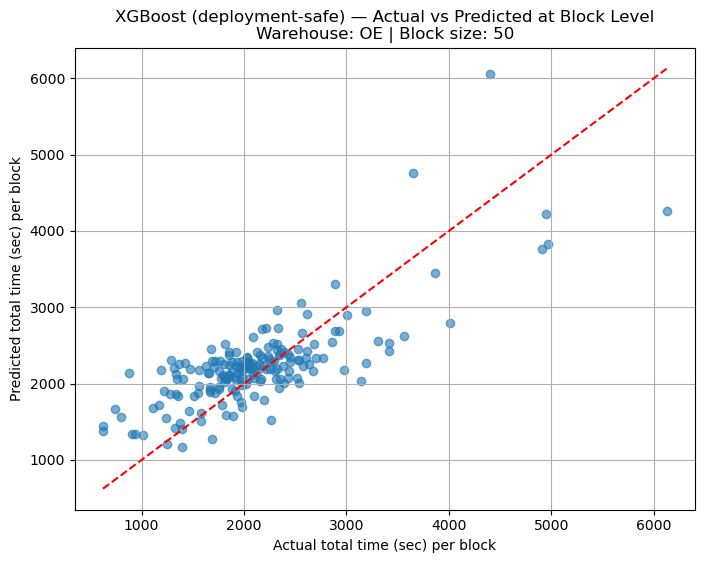

In [6]:
plot_df = block_detail_df[block_detail_df["Warehouse"] == WAREHOUSE].copy()
plot_df = plot_df[plot_df["pred"].notna()].copy()

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["actual_time"], plot_df["pred"], alpha=0.6)
plt.plot(
    [plot_df["actual_time"].min(), plot_df["actual_time"].max()],
    [plot_df["actual_time"].min(), plot_df["actual_time"].max()],
    color="red", linestyle="--"
)
plt.xlabel("Actual total time (sec) per block")
plt.ylabel("Predicted total time (sec) per block")
plt.title(f"XGBoost (deployment-safe) — Actual vs Predicted at Block Level\n"
          f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE}")
plt.grid(True)
plt.show()


In [7]:
df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, "30", MAX_TIME)
print(features)


['Weight', 'Cube', 'Quantity', 'aisle', 'level', 'UoM', 't25_products', 't25_50_products', 't50_75_products', 'other_products']


In [8]:
# ── Worker Random Intercept (Mixed Effects) ────────────────────────────────
# Fits Time_Delta_sec ~ 1 + (1|UserID) on training data only.
# Extracts per-worker effect b_j and adds it as a feature to XGBoost.
# Unseen workers at test time get effect = 0 (grand mean fallback).

def estimate_worker_effects(train_df):
    """
    Fits a random intercept model on training data.
    Returns a DataFrame with columns [UserID, worker_effect].
    worker_effect is the b_j estimate: positive = slower than average.
    """
    df_re = train_df[["UserID", "Time_Delta_sec"]].dropna().copy()
    if df_re["UserID"].nunique() < 2:
        print("  [Warning] Not enough workers — skipping worker effects")
        return pd.DataFrame({"UserID": df_re["UserID"].unique(), "worker_effect": 0.0})

    result = smf.mixedlm(
        "Time_Delta_sec ~ 1", data=df_re, groups=df_re["UserID"]
    ).fit(reml=True, disp=False)

    icc = result.cov_re.values[0][0] / (result.cov_re.values[0][0] + result.scale)
    print(f"  Grand mean: {result.fe_params['Intercept']:.1f}s | "
          f"Worker SD: {np.sqrt(result.cov_re.values[0][0]):.1f}s | ICC: {icc:.3f}")

    return pd.DataFrame({
        "UserID":        list(result.random_effects.keys()),
        "worker_effect": [float(v.iloc[0]) for v in result.random_effects.values()]
    })


all_block_results_w = []
all_block_detail_w  = []

for wc in WORKCODES:
    print(f"\n{'='*50}")
    print(f"WorkCode {wc} — + Worker Effect")
    print(f"{'='*50}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, test_days = split_by_days(df_wc)

    # Estimate worker effects on training data only — no leakage
    print("  Fitting mixed model...")
    worker_effects = estimate_worker_effects(train_df)

    # Join worker_effect — unseen workers get 0 (grand mean fallback)
    train_df = train_df.merge(worker_effects, on="UserID", how="left")
    test_df  = test_df.merge(worker_effects,  on="UserID", how="left")
    train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
    test_df["worker_effect"]  = test_df["worker_effect"].fillna(0.0)

    # Reset index — critical for block index alignment
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    y_train  = train_df["Time_Delta_sec"].astype(float)
    y_test   = test_df["Time_Delta_sec"].astype(float)

    # Add worker_effect to feature set
    feats_w = features + ["worker_effect"]
    X_train, X_test = make_X(train_df, test_df, feats_w, cat_cols)

    t0    = time.perf_counter()
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    runtime = time.perf_counter() - t0

    # Block-level evaluation
    block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_df) == 0:
        print(f"  No valid blocks for WC {wc}")
        continue

    temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
    temp["pred"] = preds
    block_rows_df = block_rows_df.merge(temp[["orig_index", "pred"]], on="orig_index", how="left")

    block_pred = (
        block_rows_df.groupby("BlockID")
        .agg(
            actual_time=("Time_Delta_sec", "sum"),
            pred=("pred", "sum"),
            WorkCode=("WorkCode", "first"),
            UserID=("UserID", "first"),
            date=("date", "first"),
            n_tasks=("Time_Delta_sec", "size"),
        )
        .reset_index()
    )

    metrics = eval_predictions(block_pred["actual_time"], block_pred["pred"])
    print(f"  Blocks: {len(block_pred)} | MAE: {metrics['mae']:.1f}s | "
          f"MAE/task: {metrics['mae']/BLOCK_SIZE:.3f}s | R²: {metrics['r2']:.4f}")

    all_block_results_w.append({
        "Warehouse": WAREHOUSE,
        "WorkCode":  wc,
        "n_blocks":  len(block_pred),
        **metrics
    })
    block_pred["Warehouse"] = WAREHOUSE
    all_block_detail_w.append(block_pred)

block_results_w_df = pd.DataFrame(all_block_results_w)
block_detail_w_df  = pd.concat(all_block_detail_w, ignore_index=True) if all_block_detail_w else pd.DataFrame()
print("\nDone.")



WorkCode 10 — + Worker Effect
  Fitting mixed model...
  Grand mean: 83.7s | Worker SD: 12.5s | ICC: 0.043
  Blocks: 6 | MAE: 758.1s | MAE/task: 15.162s | R²: -0.3035

WorkCode 20 — + Worker Effect
  Fitting mixed model...


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Grand mean: 39.2s | Worker SD: 11.1s | ICC: 0.034
  Blocks: 55 | MAE: 422.9s | MAE/task: 8.458s | R²: 0.3084

WorkCode 30 — + Worker Effect
  Fitting mixed model...
  Grand mean: 61.1s | Worker SD: 22.3s | ICC: 0.208
  Blocks: 124 | MAE: 256.6s | MAE/task: 5.132s | R²: 0.6641

Done.


In [9]:
# extract all worker effects
worker_effects_all = []
for wc in WORKCODES:
    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, _, _ = split_by_days(df_wc)
    worker_effects = estimate_worker_effects(train_df)
    worker_effects["WorkCode"] = wc
    worker_effects_all.append(worker_effects)
worker_effects_df = pd.concat(worker_effects_all, ignore_index=True)

  Grand mean: 83.7s | Worker SD: 12.5s | ICC: 0.043


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Grand mean: 39.2s | Worker SD: 11.1s | ICC: 0.034
  Grand mean: 61.1s | Worker SD: 22.3s | ICC: 0.208


In [10]:
# Summarize worker-effect distribution per WorkCode
summary_rows = []
for wc in WORKCODES:
    s = worker_effects_df.loc[worker_effects_df["WorkCode"] == wc, "worker_effect"].dropna()
    if s.empty:
        continue
    summary_rows.append({
        "WorkCode": wc,
        "n_workers": int(len(s)),
        "worker_effect_p10": float(np.percentile(s, 10)),
        "worker_effect_p25": float(np.percentile(s, 25)),
        "worker_effect_mean": float(s.mean()),
        "worker_effect_p75": float(np.percentile(s, 75)),
        "worker_effect_p90": float(np.percentile(s, 90)),
    })

worker_effect_summary_df = pd.DataFrame(summary_rows)
if not worker_effect_summary_df.empty:
    worker_effect_summary_df = worker_effect_summary_df.sort_values("WorkCode").reset_index(drop=True)
    display(worker_effect_summary_df.round(2))
else:
    print("No worker effects available.")



,WorkCode,n_workers,worker_effect_p10,worker_effect_p25,worker_effect_mean,worker_effect_p75,worker_effect_p90
0,10,16,-10.66,-6.08,0.0,5.47,15.70
1,20,23,-9.75,-5.50,0.0,4.64,9.44
2,30,37,-20.37,-17.28,0.0,11.39,31.14


In [15]:
# Chunk-level counterfactual evaluation: set all test rows to one worker_effect value
# Scenarios: p10, p25, mean, p75, p90 (warehouse of all efficient/inefficient workers)
scenario_rows = []
scenario_order = ["p5", "p25", "mean", "p75", "p90"]

for wc in WORKCODES:
    print(f"\n{'='*50}")
    print(f"WorkCode {wc} — Counterfactual worker_effect scenarios")
    print(f"{'='*50}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, _ = split_by_days(df_wc)

    # Estimate worker effects from train only
    worker_effects = estimate_worker_effects(train_df)
    if worker_effects.empty:
        print("  No worker effects estimated; skipping.")
        continue

    # Prepare train/test with per-user effects (train), unseen fallback 0.0
    train_df = train_df.merge(worker_effects, on="UserID", how="left")
    test_df = test_df.merge(worker_effects, on="UserID", how="left")
    train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
    test_df["worker_effect"] = test_df["worker_effect"].fillna(0.0)

    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    y_train = train_df["Time_Delta_sec"].astype(float)

    feats_w = features + ["worker_effect"]
    X_train, _ = make_X(train_df, test_df, feats_w, cat_cols)

    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    # Build blocks once (same rows for every scenario)
    _, block_rows_template = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_rows_template) == 0:
        print(f"  No valid blocks for WC {wc}")
        continue

    # Scenario values from this WorkCode's estimated worker effects
    s = worker_effects["worker_effect"].astype(float)
    scenario_values = {
        "p5":  float(np.percentile(s, 5)),
        "p25":  float(np.percentile(s, 25)),
        "mean": float(s.mean()),
        "p75":  float(np.percentile(s, 75)),
        "p90":  float(np.percentile(s, 90)),
    }

    wc_rows = []
    for scen in scenario_order:
        eff = scenario_values[scen]

        # Counterfactual: force all test rows to same worker_effect
        test_cf = test_df.copy()
        test_cf["worker_effect"] = eff

        _, X_test_cf = make_X(train_df, test_cf, feats_w, cat_cols)
        preds_cf = model.predict(X_test_cf)

        temp = test_cf.copy().reset_index().rename(columns={"index": "orig_index"})
        temp["pred"] = preds_cf

        block_rows_df = block_rows_template.merge(
            temp[["orig_index", "pred"]], on="orig_index", how="left"
        )

        block_pred = (
            block_rows_df.groupby("BlockID")
            .agg(
                actual_time=("Time_Delta_sec", "sum"),
                pred=("pred", "sum"),
            )
            .reset_index()
        )

        metrics = eval_predictions(block_pred["actual_time"], block_pred["pred"])
        wc_rows.append({
            "Warehouse": WAREHOUSE,
            "WorkCode": wc,
            "Scenario": scen,
            "worker_effect_set": eff,
            "n_blocks": int(len(block_pred)),
            "MAE (s)": float(metrics["mae"]),
            "R²": float(metrics["r2"]),
        })

    # % difference relative to mean scenario within each WorkCode
    mae_mean = next(r["MAE (s)"] for r in wc_rows if r["Scenario"] == "mean")
    for r in wc_rows:
        r["MAE % diff vs mean"] = ((r["MAE (s)"] - mae_mean) / mae_mean * 100) if mae_mean else np.nan
        r["MAE/task (s)"] = r["MAE (s)"] / BLOCK_SIZE

    scenario_rows.extend(wc_rows)

scenario_eval_df = pd.DataFrame(scenario_rows)
if not scenario_eval_df.empty:
    scenario_eval_df["Scenario"] = pd.Categorical(
        scenario_eval_df["Scenario"], categories=scenario_order, ordered=True
    )
    scenario_eval_df = scenario_eval_df.sort_values(["WorkCode", "Scenario"]).reset_index(drop=True)
    scenario_eval_df = scenario_eval_df[[
        "Warehouse", "WorkCode", "Scenario", "worker_effect_set", "n_blocks",
        "MAE (s)", "MAE/task (s)", "MAE % diff vs mean", "R²"
    ]]
    display(scenario_eval_df.round(3))
else:
    print("No counterfactual scenario results.")




WorkCode 10 — Counterfactual worker_effect scenarios
  Grand mean: 83.7s | Worker SD: 12.5s | ICC: 0.043

WorkCode 20 — Counterfactual worker_effect scenarios


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Grand mean: 39.2s | Worker SD: 11.1s | ICC: 0.034

WorkCode 30 — Counterfactual worker_effect scenarios
  Grand mean: 61.1s | Worker SD: 22.3s | ICC: 0.208


,Warehouse,WorkCode,Scenario,worker_effect_set,n_blocks,MAE (s),MAE/task (s),MAE % diff vs mean,R²
0,OE,10,p5,-16.040,6,1909.578,38.192,42.990,-5.622
1,OE,10,p25,-6.083,6,1451.147,29.023,8.662,-2.855
2,OE,10,mean,0.000,6,1335.464,26.709,0.000,-2.099
3,OE,10,p75,5.473,6,1142.639,22.853,-14.439,-1.424
4,OE,10,p90,15.702,6,728.041,14.561,-45.484,-0.239
5,OE,20,p5,-11.063,55,496.374,9.927,25.610,-0.025
6,OE,20,p25,-5.505,55,439.165,8.783,11.133,0.214
7,OE,20,mean,0.000,55,395.172,7.903,0.000,0.299
8,OE,20,p75,4.635,55,674.125,13.482,70.590,-0.489
9,OE,20,p90,9.443,55,708.993,14.180,79.414,-0.659


In [16]:
# Mean prediction difference vs mean-user scenario
# For each percentile scenario, compute:
# - mean predicted chunk total (50 tasks)
# - mean predicted per-task time
# - difference vs mean-user prediction

pred_diff_rows = []
scenario_order = ["p5", "p25", "mean", "p75", "p90"]

for wc in WORKCODES:
    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, _ = split_by_days(df_wc)

    worker_effects = estimate_worker_effects(train_df)
    if worker_effects.empty:
        continue

    train_df = train_df.merge(worker_effects, on="UserID", how="left")
    test_df = test_df.merge(worker_effects, on="UserID", how="left")
    train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
    test_df["worker_effect"] = test_df["worker_effect"].fillna(0.0)

    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    y_train = train_df["Time_Delta_sec"].astype(float)
    feats_w = features + ["worker_effect"]

    X_train, _ = make_X(train_df, test_df, feats_w, cat_cols)
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    _, block_rows_template = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_rows_template) == 0:
        continue

    s = worker_effects["worker_effect"].astype(float)
    scenario_values = {
        "p5": float(np.percentile(s, 5)),
        "p25": float(np.percentile(s, 25)),
        "mean": float(s.mean()),
        "p75": float(np.percentile(s, 75)),
        "p90": float(np.percentile(s, 90)),
    }

    wc_stats = {}
    for scen in scenario_order:
        eff = scenario_values[scen]

        test_cf = test_df.copy()
        test_cf["worker_effect"] = eff

        _, X_test_cf = make_X(train_df, test_cf, feats_w, cat_cols)
        preds_cf = model.predict(X_test_cf)

        temp = test_cf.copy().reset_index().rename(columns={"index": "orig_index"})
        temp["pred"] = preds_cf

        block_rows_df = block_rows_template.merge(
            temp[["orig_index", "pred"]], on="orig_index", how="left"
        )

        block_pred = (
            block_rows_df.groupby("BlockID")
            .agg(pred_total=("pred", "sum"))
            .reset_index()
        )

        mean_chunk_pred = float(block_pred["pred_total"].mean())
        mean_task_pred = mean_chunk_pred / BLOCK_SIZE

        wc_stats[scen] = {
            "Warehouse": WAREHOUSE,
            "WorkCode": wc,
            "Scenario": scen,
            "worker_effect_set": eff,
            "n_blocks": int(len(block_pred)),
            "mean_pred_chunk_total_50": mean_chunk_pred,
            "mean_pred_per_task": mean_task_pred,
        }

    mean_chunk_base = wc_stats["mean"]["mean_pred_chunk_total_50"]
    mean_task_base = wc_stats["mean"]["mean_pred_per_task"]

    for scen in scenario_order:
        r = wc_stats[scen]
        r["diff_chunk_total_vs_mean_user"] = r["mean_pred_chunk_total_50"] - mean_chunk_base
        r["diff_per_task_vs_mean_user"] = r["mean_pred_per_task"] - mean_task_base
        r["% diff_chunk_total_vs_mean_user"] = (
            (r["diff_chunk_total_vs_mean_user"] / mean_chunk_base) * 100
            if mean_chunk_base else np.nan
        )
        r["% diff_per_task_vs_mean_user"] = (
            (r["diff_per_task_vs_mean_user"] / mean_task_base) * 100
            if mean_task_base else np.nan
        )
        pred_diff_rows.append(r)

pred_diff_vs_mean_user_df = pd.DataFrame(pred_diff_rows)
if not pred_diff_vs_mean_user_df.empty:
    pred_diff_vs_mean_user_df["Scenario"] = pd.Categorical(
        pred_diff_vs_mean_user_df["Scenario"], categories=scenario_order, ordered=True
    )
    pred_diff_vs_mean_user_df = pred_diff_vs_mean_user_df.sort_values(["WorkCode", "Scenario"]).reset_index(drop=True)
    pred_diff_vs_mean_user_df = pred_diff_vs_mean_user_df[[
        "Warehouse", "WorkCode", "Scenario", "worker_effect_set", "n_blocks",
        "mean_pred_chunk_total_50", "mean_pred_per_task",
        "diff_chunk_total_vs_mean_user", "diff_per_task_vs_mean_user",
        "% diff_chunk_total_vs_mean_user", "% diff_per_task_vs_mean_user"
    ]]
    display(pred_diff_vs_mean_user_df.round(3))
else:
    print("No results for percentile mean-difference summary.")



  Grand mean: 83.7s | Worker SD: 12.5s | ICC: 0.043


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Grand mean: 39.2s | Worker SD: 11.1s | ICC: 0.034
  Grand mean: 61.1s | Worker SD: 22.3s | ICC: 0.208


,Warehouse,WorkCode,Scenario,worker_effect_set,n_blocks,mean_pred_chunk_total_50,mean_pred_per_task,diff_chunk_total_vs_mean_user,diff_per_task_vs_mean_user,% diff_chunk_total_vs_mean_user,% diff_per_task_vs_mean_user
0,OE,10,p5,-16.040,6,2833.083,56.662,-819.919,-16.398,-22.445,-22.445
1,OE,10,p25,-6.083,6,3407.284,68.146,-245.719,-4.914,-6.726,-6.726
2,OE,10,mean,0.000,6,3653.003,73.060,0.000,0.000,0.000,0.000
3,OE,10,p75,5.473,6,3861.593,77.232,208.590,4.172,5.710,5.710
4,OE,10,p90,15.702,6,4645.633,92.913,992.631,19.853,27.173,27.173
5,OE,20,p5,-11.063,55,1459.000,29.180,-470.292,-9.406,-24.376,-24.376
6,OE,20,p25,-5.505,55,1657.162,33.143,-272.129,-5.443,-14.105,-14.105
7,OE,20,mean,0.000,55,1929.291,38.586,0.000,0.000,0.000,0.000
8,OE,20,p75,4.635,55,2416.304,48.326,487.013,9.740,25.243,25.243
9,OE,20,p90,9.443,55,2465.634,49.313,536.342,10.727,27.800,27.800


In [13]:
# User counts by worker-effect percentile bands (with percentage)
# Bands: 0-10, 10-35, 35-65, 65-90, 90-100

band_labels = ["0-10", "10-35", "35-65", "65-90", "90-100"]
quantiles = [0.10, 0.35, 0.65, 0.90]

band_rows = []

for wc in WORKCODES:
    s = worker_effects_df.loc[
        worker_effects_df["WorkCode"] == wc, ["UserID", "worker_effect"]
    ].dropna().copy()

    if s.empty:
        continue

    q10, q35, q65, q90 = s["worker_effect"].quantile(quantiles).tolist()
    bins = [-np.inf, q10, q35, q65, q90, np.inf]

    s["percentile_band"] = pd.cut(
        s["worker_effect"],
        bins=bins,
        labels=band_labels,
        include_lowest=True,
        right=True,
    )

    counts = (
        s.groupby("percentile_band", observed=False)["UserID"]
        .nunique()
        .reindex(band_labels, fill_value=0)
    )
    total_users = int(counts.sum())

    for band in band_labels:
        n = int(counts.loc[band])
        band_rows.append({
            "WorkCode": wc,
            "percentile_band": band,
            "n_users": n,
            "percentage": (n / total_users * 100) if total_users else np.nan,
        })

user_percentile_band_df = pd.DataFrame(band_rows)
if not user_percentile_band_df.empty:
    user_percentile_band_df["percentile_band"] = pd.Categorical(
        user_percentile_band_df["percentile_band"], categories=band_labels, ordered=True
    )
    user_percentile_band_df = user_percentile_band_df.sort_values(
        ["WorkCode", "percentile_band"]
    ).reset_index(drop=True)
    display(user_percentile_band_df.round({"percentage": 2}))
else:
    print("No user-band summary available.")



,WorkCode,percentile_band,n_users,percentage
0,10,0-10,2,12.50
1,10,10-35,4,25.00
2,10,35-65,4,25.00
3,10,65-90,4,25.00
4,10,90-100,2,12.50
5,20,0-10,3,13.04
6,20,10-35,5,21.74
7,20,35-65,7,30.43
8,20,65-90,5,21.74
9,20,90-100,3,13.04
